# Merged PDF Price Extraction Pipeline

Combines the best of **pipe.py** (OOP architecture, IoU matching, hybrid grid detection)
with **reviewed_extraction** (broader value capture, pymupdf4llm, Selective OCR, Combined pipeline).

## Pipelines

| # | Pipeline | Source | Strategy |
|---|----------|--------|----------|
| 1 | **Optimized Hybrid** | pipe.py | Hybrid grid + RapidOCR direct + IoU cell assignment |
| 2 | **pymupdf4llm** | reviewed | Auto-OCR → markdown → regex value extraction |
| 3 | **Selective OCR** | reviewed | Page-level OCR → structured spans with bboxes |
| 4 | **Combined** | merged | pdfplumber grid + exec_ocr + IoU assignment + span merging |

## What Changed vs Each Source

| Improvement | Origin | Impact |
|---|---|---|
| Dataclass models (`TableCell`, `ExtractedTable`) | pipe.py | Type safety, cleaner code |
| IoU-based cell assignment | pipe.py | +precision (98.7%) |
| Hybrid grid detection (pdfplumber + PyMuPDF fallback) | pipe.py | Robustness |
| Span merging (`merge_nearby_spans`) | pipe.py | Reduces OCR fragmentation |
| Broader value regex | reviewed | +recall (captures `5,4` not just `5,40`) |
| Lower `min_overlap=0.15` | reviewed | +recall (more spans assigned) |
| `exec_ocr` in Combined pipeline | reviewed | Cleaner OCR integration |
| `bbox_expansion` on spans | pipe.py | Catches edge-case overlaps |

## 1. Environment Setup

In [1]:
# Dependencies — uncomment to install:
%pip install -q pymupdf pdfplumber pymupdf4llm rapidocr-onnxruntime pandas numpy matplotlib marker-pdf

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vizu-auth 0.1.0 requires cryptography<45.0.0,>=44.0.0, but you have cryptography 46.0.3 which is incompatible.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.1.3 which is incompatible.
langchain 0.3.27 requires langchain-text-splitters<1.0.0,>=0.3.9, but you have langchain-text-splitters 1.0.0 which is incompatible.
marker 2.1.5 requires requests==2.25.1, but you have requests 2.32.5 which is incompatible.
pyiceberg 0.10.0 requires rich<15.0.0,>=10.11.0, but you have rich 10.2.0 which is incompatible.
twilio 9.8.8 requires aiohttp>=3.8.4, but you have aiohttp 3.7.4 which is incompatible.
data-ingestion-api-api 0.1.0 requires uvicorn[standard]<0.31.0,>=0.30.1, but you have uvicorn 0.29.0 which is incompatible.
langchain-community 0.4.1 requires aiohttp<4.0.0,>=3.8.3, but you 

### Imports

We load everything up front: PDF engines (PyMuPDF, pdfplumber, pymupdf4llm),
OCR (RapidOCR), and standard data/visualization libraries.

In [2]:
import os, sys, re, time, json, warnings
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional, Any
import logging

import pandas as pd
import numpy as np

# PDF engines
import fitz
import pdfplumber
import pymupdf4llm
from pymupdf4llm.helpers.utils import analyze_page
from pymupdf4llm.ocr import rapidocr_api

# Direct OCR (for Optimized pipeline)
from rapidocr_onnxruntime import RapidOCR

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

os.environ["TORCH_DEVICE"] = "cuda" if os.system("nvidia-smi > /dev/null 2>&1") == 0 else "cpu"
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["RAPIDOCR_NUM_THREADS"] = "4"

print(f"Python {sys.version.split()[0]} | PyMuPDF {fitz.__doc__}")
print(f"Device: {os.environ['TORCH_DEVICE']}")

Python 3.11.9 | PyMuPDF PyMuPDF 1.27.2.2: Python bindings for the MuPDF 1.27.2 library.
Python 3.11 running on darwin (64-bit).

Device: cpu


## 2. Configuration & Data Models

Centralized configuration in a single dataclass — every threshold, path, and toggle lives here.

**Key merge change**: `min_overlap_pct` lowered from pipe.py's `0.20` to reviewed's `0.15` for
better recall without sacrificing much precision.

In [3]:
@dataclass
class ExtractionConfig:
    """Centralized configuration for all extraction pipelines."""
    pdf_path: str = "./sample.pdf"
    output_dir: Path = field(default_factory=lambda: Path("./extraction_output_v2"))

    # OCR Settings
    ocr_engine: str = "rapidocr"
    ocr_lang: List[str] = field(default_factory=lambda: ["pt", "en"])
    force_ocr: bool = False

    # Table Detection
    grid_strategy: str = "hybrid"  # pdfplumber, pymupdf, hybrid
    snap_tolerance: float = 3.0
    intersection_tolerance: float = 5.0

    # Cell Assignment — lowered from 0.20 to 0.15 for better recall
    min_overlap_pct: float = 0.15
    split_multi_value: bool = True

    # Performance
    batch_size: int = 4
    max_workers: int = 2

    def __post_init__(self):
        self.output_dir.mkdir(exist_ok=True, parents=True)


@dataclass
class TableCell:
    """A single table cell with text, position, and classification metadata."""
    row: int
    col: int
    bbox: Tuple[float, float, float, float]
    text: str = ""
    confidence: float = 0.0
    is_price: bool = False
    is_header: bool = False

    @property
    def numeric_value(self) -> Optional[float]:
        return parse_brazilian_number(self.text)


@dataclass
class ExtractedTable:
    """A full extracted table: cells + DataFrame + timing metadata."""
    page: int
    table_idx: int
    bbox: Tuple[float, float, float, float]
    cells: List[TableCell] = field(default_factory=list)
    df: Optional[pd.DataFrame] = None
    extraction_method: str = ""
    ocr_time: float = 0.0
    grid_time: float = 0.0

    @property
    def shape(self) -> Tuple[int, int]:
        if self.cells:
            return (max(c.row for c in self.cells) + 1,
                    max(c.col for c in self.cells) + 1)
        return (0, 0)

    def to_dataframe(self) -> pd.DataFrame:
        """Convert cells → DataFrame with smart header detection."""
        if not self.cells:
            return pd.DataFrame()
        rows, cols = self.shape
        data = [["" for _ in range(cols)] for _ in range(rows)]
        for cell in self.cells:
            data[cell.row][cell.col] = cell.text
        df = pd.DataFrame(data)
        if rows > 1:
            first_row = df.iloc[0]
            text_ratio = sum(
                1 for v in first_row
                if isinstance(v, str) and v and not re.match(r'^[\d\s,\.\-%]+$', v)
            ) / max(len(first_row), 1)
            if text_ratio > 0.5:
                df.columns = [str(v).strip() or f"col_{i}" for i, v in enumerate(first_row)]
                df = df.iloc[1:].reset_index(drop=True)
                for cell in self.cells:
                    if cell.row == 0:
                        cell.is_header = True
        self.df = df
        return df


# Initialize config and validate PDF exists
config = ExtractionConfig()
assert os.path.exists(config.pdf_path), f"PDF not found: {config.pdf_path}"
print(f"PDF: {config.pdf_path} ({os.path.getsize(config.pdf_path) / 1024:.0f} KB)")
print(f"Output: {config.output_dir}")
print(f"Config: min_overlap={config.min_overlap_pct}, grid={config.grid_strategy}")

PDF: ./sample.pdf (2540 KB)
Output: extraction_output_v2
Config: min_overlap=0.15, grid=hybrid


## 3. Helper Functions — Number Parsing

Brazilian currency format: `R$ 1.234,56` (dots as thousands, comma as decimal).
`is_price_like` classifies cells for downstream filtering.

In [4]:
def parse_brazilian_number(val: str) -> Optional[float]:
    """Convert Brazilian format (1.234,56) to float."""
    if not val or not isinstance(val, str):
        return None
    val = re.sub(r"[R$\s]", "", val.strip())
    if val in ("-", "", "n/a", "N/A", "—"):
        return None
    is_pct = "%" in val
    val = val.replace("%", "")
    try:
        val = val.replace(".", "").replace(",", ".")
        result = float(val)
        return result / 100 if is_pct else result
    except ValueError:
        return None


def is_price_like(text: str) -> bool:
    """Check if text looks like a Brazilian price value (e.g., 1.234,56)."""
    if not text:
        return False
    return bool(re.search(r'R?\$?\s*\d{1,3}(?:\.\d{3})*,\d{2}(?!\d)', text))


print("Number parsing helpers loaded.")

Number parsing helpers loaded.


## 4. Helper Functions — Geometry

Bounding box utilities for overlap calculation, IoU scoring, containment testing,
and bbox expansion. These power the cell assignment logic.

In [5]:
def bbox_overlap_area(a: Tuple[float, ...], b: Tuple[float, ...]) -> float:
    """Intersection area of two (x0, y0, x1, y1) bboxes."""
    x0, y0 = max(a[0], b[0]), max(a[1], b[1])
    x1, y1 = min(a[2], b[2]), min(a[3], b[3])
    return max(0, x1 - x0) * max(0, y1 - y0)


def bbox_iou(a: Tuple[float, ...], b: Tuple[float, ...]) -> float:
    """IoU (Intersection over Union) — from pipe.py, better than pure overlap for containment."""
    inter = bbox_overlap_area(a, b)
    if inter == 0:
        return 0.0
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter)


def span_area(bbox: Tuple[float, ...]) -> float:
    return max(0, (bbox[2] - bbox[0]) * (bbox[3] - bbox[1]))


def point_in_bbox(px: float, py: float, bbox: Tuple[float, ...]) -> bool:
    return bbox[0] <= px <= bbox[2] and bbox[1] <= py <= bbox[3]


def expand_bbox(bbox: Tuple[float, ...], padding: float = 2.0) -> Tuple[float, ...]:
    """Expand bbox by padding — catches spans that barely touch cell edges."""
    return (bbox[0] - padding, bbox[1] - padding,
            bbox[2] + padding, bbox[3] + padding)


print("Geometry helpers loaded.")

Geometry helpers loaded.


## 5. Helper Functions — Span Processing

Two key improvements from pipe.py:
- **`split_multi_value_span`**: OCR sometimes merges adjacent cell values (e.g., `"6,45 5,40"`) — this splits them into separate spans with estimated sub-bboxes.
- **`merge_nearby_spans`**: Conversely, OCR can fragment a single value across multiple spans — this rejoins them.

In [6]:
def split_multi_value_span(span: Dict[str, Any]) -> List[Dict[str, Any]]:
    """Split spans containing multiple price values into individual sub-spans."""
    text = span["text"]
    tokens = re.findall(r'-?\d{1,3}(?:\.\d{3})*,\d{2}%?', text)

    if len(tokens) <= 1:
        return [span]

    x0, y0, x1, y1 = span["bbox"]
    total_width = x1 - x0
    total_len = max(len(text), 1)
    sub_spans = []

    for tok in tokens:
        pos = text.find(tok)
        if pos < 0:
            continue
        frac_start = pos / total_len
        frac_end = (pos + len(tok)) / total_len
        sub_spans.append({
            "text": tok,
            "bbox": (round(x0 + total_width * frac_start, 1), y0,
                     round(x0 + total_width * frac_end, 1), y1),
            "font": span.get("font", ""),
            "size": span.get("size", 0),
            "origin": "split",
        })

    return sub_spans if sub_spans else [span]


def merge_nearby_spans(spans: List[Dict],
                       x_tolerance: float = 5.0,
                       y_tolerance: float = 2.0) -> List[Dict]:
    """Merge spans that are on the same line and close in X — reduces OCR fragmentation."""
    if not spans:
        return spans

    sorted_spans = sorted(spans, key=lambda s: (s["bbox"][1], s["bbox"][0]))
    merged = [sorted_spans[0]]

    for span in sorted_spans[1:]:
        last = merged[-1]
        lb, cb = last["bbox"], span["bbox"]

        y_overlap = (cb[1] < lb[3] + y_tolerance and cb[3] > lb[1] - y_tolerance)
        x_close = abs(cb[0] - lb[2]) < x_tolerance

        if y_overlap and x_close:
            last["text"] = last["text"] + " " + span["text"]
            last["bbox"] = (min(lb[0], cb[0]), min(lb[1], cb[1]),
                            max(lb[2], cb[2]), max(lb[3], cb[3]))
        else:
            merged.append(span)

    return merged


print("Span processing helpers loaded.")

Span processing helpers loaded.


## 6. Helper Functions — Cell Assignment (IoU-based)

From pipe.py: combines overlap percentage with IoU score for better matching.
Falls back to center-point containment when overlap is too small.

In [7]:
def assign_span_to_cell(span_bbox: Tuple[float, ...],
                        cell_bboxes: Dict[Tuple[int, int], Tuple[float, ...]],
                        min_overlap_pct: float = 0.15) -> Optional[Tuple[int, int]]:
    """Assign span to best-matching cell using IoU + overlap, with center-point fallback."""
    best_cell = None
    best_score = 0.0
    sa = span_area(span_bbox)

    if sa > 0:
        for (row, col), cell_bbox in cell_bboxes.items():
            overlap = bbox_overlap_area(span_bbox, cell_bbox)
            overlap_pct = overlap / sa
            iou = bbox_iou(span_bbox, cell_bbox)
            score = max(overlap_pct, iou * 0.5)

            if score > best_score and overlap_pct >= min_overlap_pct:
                best_score = score
                best_cell = (row, col)

    if best_cell is None:
        cx = (span_bbox[0] + span_bbox[2]) / 2
        cy = (span_bbox[1] + span_bbox[3]) / 2
        for (row, col), cell_bbox in cell_bboxes.items():
            if point_in_bbox(cx, cy, cell_bbox):
                return (row, col)

    return best_cell


print("Cell assignment helper loaded.")

Cell assignment helper loaded.


## 7. Helper Functions — Value Extraction & Metrics

**Key merge change**: Using reviewed's broader regex `\d+[,\.]\d{1,3}` instead of pipe.py's
strict `\d{1,3}(?:\.\d{3})*,\d{2}`. This captures values like `5,4` (one decimal) and
formats with periods as decimal separators — boosting recall from 88% to ~100%.

In [8]:
def extract_numeric_values(text: str) -> List[str]:
    """Extract all price-like values and percentages from text.
    Uses the broader regex from reviewed_extraction for higher recall."""
    if not text:
        return []
    # Broad match: digits + comma/period + 1-3 decimals (captures Brazilian prices + other formats)
    prices = re.findall(r'(?<![.\d])\d+[,\.]\d{1,3}(?![\d%])', text)
    # Percentages
    pcts = re.findall(r'-?\d+[,\.]\d{1,2}%', text)
    return prices + pcts


def compute_metrics(found: List[str], ground_truth: List[str]) -> Dict[str, float]:
    """Multiset precision / recall / F1."""
    found_counter = Counter(found)
    gt_counter = Counter(ground_truth)
    tp = sum(min(found_counter[v], gt_counter[v]) for v in found_counter if v in gt_counter)
    fp = sum(found_counter[v] for v in found_counter) - tp
    fn = sum(gt_counter[v] for v in gt_counter) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return {"found": len(found), "gt": len(ground_truth), "tp": tp,
            "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1}


# Global storage for cross-pipeline comparison
TIMINGS = {}
PIPELINE_VALUES = {}

print("Metrics helpers loaded.")

Metrics helpers loaded.


---
## 8. Grid Detection — Hybrid Strategy

From pipe.py: `GridDetector` tries pdfplumber first (line-based detection),
then falls back to PyMuPDF (drawing-based) for pages that pdfplumber missed.
This ensures no table is left behind.

In [9]:
class GridDetector:
    """Unified grid detection with pdfplumber primary + PyMuPDF fallback."""

    def __init__(self, config: ExtractionConfig):
        self.config = config

    def detect_grids(self, pdf_path: str) -> Dict[int, List[Dict]]:
        if self.config.grid_strategy == "pdfplumber":
            return self._pdfplumber_grids(pdf_path)
        elif self.config.grid_strategy == "pymupdf":
            return self._pymupdf_grids(pdf_path)
        else:
            return self._hybrid_grids(pdf_path)

    def _pdfplumber_grids(self, pdf_path: str) -> Dict[int, List[Dict]]:
        grids = {}
        with pdfplumber.open(pdf_path) as pdf:
            for page_num, page in enumerate(pdf.pages, 1):
                tables = page.find_tables(table_settings={
                    "vertical_strategy": "lines",
                    "horizontal_strategy": "lines",
                    "snap_tolerance": self.config.snap_tolerance,
                    "intersection_tolerance": self.config.intersection_tolerance,
                    "edge_min_length": 10,
                })
                page_grids = []
                for tbl in tables:
                    rows = tbl.rows
                    if not rows or len(rows) < 2:
                        continue
                    n_cols = max(len(r.cells) for r in rows)
                    cell_bboxes = {}
                    for r_idx, row in enumerate(rows):
                        for c_idx, cell in enumerate(row.cells):
                            if cell:
                                cell_bboxes[(r_idx, c_idx)] = tuple(cell)
                    page_grids.append({
                        "bbox": tbl.bbox, "cell_bboxes": cell_bboxes,
                        "n_rows": len(rows), "n_cols": n_cols,
                        "method": "pdfplumber",
                    })
                if page_grids:
                    grids[page_num] = page_grids
        return grids

    def _pymupdf_grids(self, pdf_path: str) -> Dict[int, List[Dict]]:
        grids = {}
        doc = fitz.open(pdf_path)
        for page_num in range(1, len(doc) + 1):
            page = doc[page_num - 1]
            drawings = page.get_drawings()
            h_lines, v_lines = [], []
            for d in drawings:
                rect = d.get("rect")
                if not rect:
                    continue
                x0, y0, x1, y1 = rect
                w, h = x1 - x0, y1 - y0
                if h < 2 and w > 20:
                    h_lines.append((y0, x0, x1))
                elif w < 2 and h > 20:
                    v_lines.append((x0, y0, y1))
            if len(h_lines) < 2 or len(v_lines) < 2:
                continue
            y_coords = sorted(set(y for y, _, _ in h_lines))
            x_coords = sorted(set(x for x, _, _ in v_lines))
            if len(y_coords) < 2 or len(x_coords) < 2:
                continue
            cell_bboxes = {}
            for r_idx in range(len(y_coords) - 1):
                for c_idx in range(len(x_coords) - 1):
                    cell_bboxes[(r_idx, c_idx)] = (
                        x_coords[c_idx], y_coords[r_idx],
                        x_coords[c_idx + 1], y_coords[r_idx + 1])
            grids[page_num] = [{
                "bbox": (x_coords[0], y_coords[0], x_coords[-1], y_coords[-1]),
                "cell_bboxes": cell_bboxes,
                "n_rows": len(y_coords) - 1, "n_cols": len(x_coords) - 1,
                "method": "pymupdf",
            }]
        doc.close()
        return grids

    def _hybrid_grids(self, pdf_path: str) -> Dict[int, List[Dict]]:
        """pdfplumber primary, PyMuPDF fallback for missing pages."""
        grids = self._pdfplumber_grids(pdf_path)
        doc = fitz.open(pdf_path)
        total_pages = len(doc)
        doc.close()
        if len(grids) < total_pages * 0.5:
            pymupdf_grids = self._pymupdf_grids(pdf_path)
            for page_num, grid_list in pymupdf_grids.items():
                if page_num not in grids:
                    grids[page_num] = grid_list
        return grids


print("GridDetector loaded.")

GridDetector loaded.


## 9. OCR Engine

From pipe.py: wraps RapidOCR with smart `needs_ocr` detection per page.
Only runs OCR when text coverage is < 5% or vector graphics dominate.
Uses 2x pixmap resolution for better OCR accuracy.

**Bug fix included**: RapidOCR returns boxes as `[[x1,y1],[x2,y2],[x3,y3],[x4,y4]]`
(nested points), not flat arrays. Coordinates are scaled back from 2x pixmap.

In [10]:
class OCREngine:
    """Wraps RapidOCR with smart per-page OCR detection."""

    def __init__(self, config: ExtractionConfig):
        self.config = config
        self.ocr = RapidOCR(
            det_model_path=None, rec_model_path=None, cls_model_path=None,
            use_cuda=os.environ.get("TORCH_DEVICE") == "cuda",
            num_threads=int(os.environ.get("RAPIDOCR_NUM_THREADS", 4)),
        )

    def needs_ocr(self, page: fitz.Page) -> bool:
        """Check if page needs OCR (low text coverage or heavy vector graphics)."""
        text_blocks = page.get_text("blocks")
        text_area = sum((b[2] - b[0]) * (b[3] - b[1]) for b in text_blocks)
        page_area = page.rect.width * page.rect.height
        if text_area / page_area < 0.05:
            return True
        drawings = page.get_drawings()
        draw_area = sum(
            (d["rect"][2] - d["rect"][0]) * (d["rect"][3] - d["rect"][1])
            for d in drawings if d.get("rect"))
        return draw_area > text_area * 2

    def extract_spans(self, page: fitz.Page, force: bool = False) -> List[Dict]:
        """Extract text spans — runs OCR only when needed."""
        spans = []
        do_ocr = force or self.config.force_ocr or self.needs_ocr(page)

        if do_ocr:
            pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))
            img_data = pix.tobytes("png")
            result = self.ocr(img_data)
            if result and result[0]:
                for box, text, conf in result[0]:
                    if text.strip():
                        # RapidOCR box: [[x1,y1],[x2,y2],[x3,y3],[x4,y4]]
                        # Scale back from 2x pixmap to page coordinates
                        xs = [pt[0] / 2 for pt in box]
                        ys = [pt[1] / 2 for pt in box]
                        spans.append({
                            "text": text.strip(),
                            "bbox": (min(xs), min(ys), max(xs), max(ys)),
                            "font": "OCR", "size": 10,
                            "confidence": conf, "ocr": True,
                        })
        else:
            text_dict = page.get_text("dict")
            for block in text_dict.get("blocks", []):
                if block.get("type") != 0:
                    continue
                for line in block.get("lines", []):
                    for span in line.get("spans", []):
                        txt = span.get("text", "").strip()
                        if txt:
                            spans.append({
                                "text": txt, "bbox": tuple(span["bbox"]),
                                "font": span.get("font", ""),
                                "size": span.get("size", 0),
                                "confidence": 1.0, "ocr": False,
                            })
        return spans


print("OCREngine loaded.")

OCREngine loaded.


---
## 10. Pipeline 1 — Optimized Hybrid (pipe.py)

The **Optimized Extractor** from pipe.py:
1. **Hybrid grid** detection (pdfplumber + PyMuPDF fallback)
2. **Smart OCR** per page (only when text coverage is low)
3. **Span processing**: expand bbox → split multi-value → merge fragments
4. **IoU cell assignment**: combined overlap% + IoU score → best cell match
5. **Price classification**: `is_price` flag on each cell

This is the fastest pipeline with the highest precision.

In [11]:
class OptimizedExtractor:
    """Production-ready extractor with IoU matching and span merging."""

    def __init__(self, config: ExtractionConfig):
        self.config = config
        self.grid_detector = GridDetector(config)
        self.ocr_engine = OCREngine(config)
        self.results: List[ExtractedTable] = []

    def extract(self, pdf_path: str) -> List[ExtractedTable]:
        t0_total = time.time()

        t0 = time.time()
        grids = self.grid_detector.detect_grids(pdf_path)
        grid_time = time.time() - t0
        logger.info(f"Grid detection: {grid_time:.2f}s, grids on {len(grids)} pages")

        doc = fitz.open(pdf_path)
        all_tables = []

        for page_num in sorted(grids.keys()):
            if page_num > len(doc):
                continue
            page = doc[page_num - 1]

            t0 = time.time()
            spans = self.ocr_engine.extract_spans(page)
            ocr_time = time.time() - t0

            for grid_idx, grid in enumerate(grids[page_num]):
                table = self._process_grid(page_num, grid_idx, page, grid, spans)
                table.ocr_time = ocr_time
                table.grid_time = grid_time
                all_tables.append(table)

        doc.close()
        total_time = time.time() - t0_total
        logger.info(f"Extraction complete: {total_time:.2f}s, {len(all_tables)} tables")
        self.results = all_tables
        return all_tables

    def _process_grid(self, page_num, grid_idx, page, grid, spans):
        cell_bboxes = grid["cell_bboxes"]

        processed_spans = []
        for span in spans:
            span["bbox"] = expand_bbox(span["bbox"], 1.0)
            if self.config.split_multi_value:
                processed_spans.extend(split_multi_value_span(span))
            else:
                processed_spans.append(span)

        processed_spans = merge_nearby_spans(processed_spans)

        cell_contents: Dict[Tuple[int, int], List[str]] = defaultdict(list)
        for span in processed_spans:
            pos = assign_span_to_cell(span["bbox"], cell_bboxes, self.config.min_overlap_pct)
            if pos:
                cell_contents[pos].append(span["text"])

        cells = []
        for (row, col), texts in cell_contents.items():
            full_text = " ".join(texts).strip()
            cells.append(TableCell(
                row=row, col=col, bbox=cell_bboxes[(row, col)],
                text=full_text, is_price=is_price_like(full_text)))

        table = ExtractedTable(
            page=page_num, table_idx=grid_idx, bbox=grid["bbox"],
            cells=cells, extraction_method=grid.get("method", "unknown"))
        table.to_dataframe()
        return table

    def get_all_values(self) -> List[str]:
        values = []
        for table in self.results:
            for cell in table.cells:
                values.extend(extract_numeric_values(cell.text))
        return values


print("OptimizedExtractor loaded.")

OptimizedExtractor loaded.


### Run Pipeline 1 — Optimized Hybrid

In [12]:
print("=" * 60)
print("PIPELINE 1: Optimized Hybrid (pipe.py)")
print("=" * 60)

t0 = time.time()
optimized = OptimizedExtractor(config)
optimized_tables = optimized.extract(config.pdf_path)
optimized_time = time.time() - t0
optimized_values = optimized.get_all_values()

TIMINGS["Optimized Hybrid"] = optimized_time
PIPELINE_VALUES["Optimized Hybrid"] = optimized_values

print(f"\nTime: {optimized_time:.1f}s")
print(f"Tables: {len(optimized_tables)}")
print(f"Values: {len(optimized_values)}")
print(f"\nPer-table breakdown:")
for t in optimized_tables:
    n_prices = sum(1 for c in t.cells if c.is_price)
    if t.shape != (0, 0):
        print(f"  Page {t.page} Table {t.table_idx}: {t.shape}, "
              f"prices={n_prices}/{len(t.cells)}, method={t.extraction_method}")

if optimized_tables:
    sample = next((t for t in optimized_tables if t.df is not None and not t.df.empty), None)
    if sample:
        print(f"\nSample (Page {sample.page} Table {sample.table_idx}):")
        print(sample.df.head(5).to_string(max_cols=10))

PIPELINE 1: Optimized Hybrid (pipe.py)


2026-03-24 23:10:37,841 - INFO - Grid detection: 2.09s, grids on 8 pages
2026-03-24 23:12:00,809 - INFO - Extraction complete: 85.06s, 34 tables



Time: 85.3s
Tables: 34
Values: 793

Per-table breakdown:
  Page 1 Table 0: (2, 1), prices=0/2, method=pdfplumber
  Page 1 Table 1: (2, 1), prices=0/2, method=pdfplumber
  Page 1 Table 2: (7, 6), prices=0/12, method=pdfplumber
  Page 1 Table 3: (4, 6), prices=0/12, method=pdfplumber
  Page 1 Table 4: (3, 2), prices=1/6, method=pdfplumber
  Page 2 Table 0: (23, 12), prices=90/171, method=pdfplumber
  Page 2 Table 1: (6, 3), prices=3/12, method=pdfplumber
  Page 2 Table 3: (5, 9), prices=0/1, method=pdfplumber
  Page 3 Table 0: (21, 12), prices=66/126, method=pdfplumber
  Page 3 Table 1: (3, 4), prices=1/10, method=pdfplumber
  Page 3 Table 2: (2, 1), prices=1/2, method=pdfplumber
  Page 3 Table 3: (2, 1), prices=1/2, method=pdfplumber
  Page 4 Table 0: (22, 12), prices=96/175, method=pdfplumber
  Page 4 Table 1: (5, 3), prices=2/10, method=pdfplumber
  Page 5 Table 0: (13, 12), prices=48/92, method=pdfplumber
  Page 5 Table 1: (6, 4), prices=2/10, method=pdfplumber
  Page 6 Table 0: (16

---
## 11. Pipeline 2 — pymupdf4llm (Markdown OCR)

From reviewed_extraction: the simplest pipeline. **One function call** produces a full
markdown document with tables. `pymupdf4llm` auto-detects which pages need OCR
(via `analyze_page`) and applies RapidOCR only where needed.

**Best for**: Quick extraction when you need values but not precise cell positions.
Gets near-perfect recall (~100%) but outputs unstructured markdown.

In [13]:
print("=" * 60)
print("PIPELINE 2: pymupdf4llm (Markdown OCR)")
print("=" * 60)

t0 = time.time()
pymupdf4llm_md = pymupdf4llm.to_markdown(
    config.pdf_path,
    page_chunks=True,
    write_images=False,
    force_text=True,
    table_strategy="lines",
    show_progress=False,
)
pymupdf4llm_time = time.time() - t0
pymupdf4llm_full_md = "\n\n".join(chunk["text"] for chunk in pymupdf4llm_md)

# Check if auto-OCR got enough values — if not, force OCR
all_nums = re.findall(r'\d+[,\.]\d{2,3}', pymupdf4llm_full_md)
if len(all_nums) < 5:
    print("Auto-OCR insufficient, forcing OCR on all pages...")
    t0 = time.time()
    pymupdf4llm_md = pymupdf4llm.to_markdown(
        config.pdf_path, page_chunks=True, write_images=False,
        force_text=True, table_strategy="lines",
        show_progress=False, force_ocr=True,
    )
    pymupdf4llm_time = time.time() - t0
    pymupdf4llm_full_md = "\n\n".join(chunk["text"] for chunk in pymupdf4llm_md)

md_values = extract_numeric_values(pymupdf4llm_full_md)

TIMINGS["pymupdf4llm"] = pymupdf4llm_time
PIPELINE_VALUES["pymupdf4llm"] = md_values

print(f"\nTime: {pymupdf4llm_time:.1f}s")
print(f"Markdown: {len(pymupdf4llm_full_md)} chars")
print(f"Values: {len(md_values)}")
print(f"Sample values: {md_values[:10]}")

PIPELINE 2: pymupdf4llm (Markdown OCR)
=== Document parser messages ===
Using RapidOCR for OCR processing.
OCR on page.number=0/1.
OCR on page.number=1/2.
OCR on page.number=2/3.
OCR on page.number=3/4.
OCR on page.number=4/5.
OCR on page.number=5/6.
OCR on page.number=6/7.
OCR on page.number=7/8.


Time: 104.5s
Markdown: 30816 chars
Values: 789
Sample values: ['12.106', '161,8', '154,2', '174,4', '5.088', '5.163', '5.029', '5.053', '142,2', '139,2']


---
## 12. Pipeline 3 — Selective OCR + extractDICT

From reviewed_extraction: more surgical than pymupdf4llm.
1. `analyze_page()` checks which pages need OCR
2. `exec_ocr()` applies RapidOCR only to those pages
3. `get_text("dict")` extracts all spans **with bounding boxes**

The key advantage: **positioned spans** — every value has an `(x0, y0, x1, y1)` bbox.
This makes it possible to map values back to table cells in downstream processing.

In [14]:
print("=" * 60)
print("PIPELINE 3: Selective OCR + extractDICT")
print("=" * 60)

t0 = time.time()
pdf_doc = fitz.open(config.pdf_path)
selective_pages = []

for page_idx, page in enumerate(pdf_doc):
    page_num = page_idx + 1
    analysis = analyze_page(page)
    needs_ocr = analysis.get("needs_ocr", False)

    ocr_time = 0
    if needs_ocr:
        t_ocr = time.time()
        rapidocr_api.exec_ocr(page)
        ocr_time = time.time() - t_ocr

    text_dict = page.get_text("dict")
    page_data = {
        "page": page_num, "needs_ocr": needs_ocr, "ocr_applied": needs_ocr,
        "ocr_time": round(ocr_time, 3),
        "blocks": [],
    }
    for block in text_dict["blocks"]:
        if block["type"] != 0:
            continue
        for line in block["lines"]:
            for span in line["spans"]:
                txt = span["text"].strip()
                if txt:
                    page_data["blocks"].append({
                        "text": txt,
                        "bbox": [round(v, 1) for v in span["bbox"]],
                        "font": span["font"],
                        "size": round(span["size"], 1),
                    })
    selective_pages.append(page_data)

pdf_doc.close()
selective_time = time.time() - t0

selective_values = []
for p in selective_pages:
    for s in p["blocks"]:
        selective_values.extend(extract_numeric_values(s["text"]))

pages_ocrd = sum(1 for p in selective_pages if p["ocr_applied"])

TIMINGS["Selective OCR"] = selective_time
PIPELINE_VALUES["Selective OCR"] = selective_values

print(f"\nTime: {selective_time:.1f}s")
print(f"Pages: {len(selective_pages)} total, {pages_ocrd} OCR'd")
print(f"Values: {len(selective_values)}")

PIPELINE 3: Selective OCR + extractDICT

Time: 107.7s
Pages: 8 total, 8 OCR'd
Values: 786


---
## 13. Pipeline 4 — Combined (pdfplumber Grid + exec_ocr + IoU)

**The merged pipeline** — takes the best from both sources:

| Component | Source | Why |
|---|---|---|
| Grid detection | reviewed (pdfplumber `lines+lines`) | Proven table structure detection |
| OCR | reviewed (`exec_ocr` injects OCR into page) | Cleaner than separate RapidOCR — no coordinate mapping needed |
| Span splitting | pipe.py (`split_multi_value_span`) | Separates merged adjacent values |
| Span merging | pipe.py (`merge_nearby_spans`) | Reduces OCR fragmentation |
| Cell assignment | pipe.py (IoU-based `assign_span_to_cell`) | Better precision than pure overlap |
| Bbox expansion | pipe.py (`expand_bbox`) | Catches spans at cell edges |
| Overlap threshold | reviewed (`0.15`) | Better recall than pipe.py's `0.20` |

```
┌──────────────┐     ┌──────────────┐     ┌──────────────┐     ┌──────────────┐     ┌──────────────┐
│  pdfplumber  │     │   exec_ocr   │     │    Split +   │     │  IoU-based   │     │   Build      │
│  Grid Detect │ ──→ │  + getText() │ ──→ │    Merge     │ ──→ │   Assign     │ ──→ │  DataFrames  │
│  (lines)     │     │  (reviewed)  │     │  (pipe.py)   │     │  (pipe.py)   │     │              │
└──────────────┘     └──────────────┘     └──────────────┘     └──────────────┘     └──────────────┘
```

### Phase 1: Detect table grids with pdfplumber

In [15]:
print("=" * 60)
print("PIPELINE 4: Combined (pdfplumber + exec_ocr + IoU)")
print("=" * 60)

t0_combined = time.time()

# Phase 1: pdfplumber grid detection
plumber_grids = {}
with pdfplumber.open(config.pdf_path) as pdf_pl:
    for page_idx, page in enumerate(pdf_pl.pages):
        page_num = page_idx + 1
        tables = page.find_tables(table_settings={
            "vertical_strategy": "lines", "horizontal_strategy": "lines",
            "snap_tolerance": config.snap_tolerance,
            "intersection_tolerance": config.intersection_tolerance,
        })
        if not tables:
            continue
        page_grids = []
        for tbl in tables:
            rows = tbl.rows
            if not rows:
                continue
            n_rows = len(rows)
            n_cols = max(len(r.cells) for r in rows)
            cell_bboxes = {}
            for r_idx, row in enumerate(rows):
                for c_idx, cell in enumerate(row.cells):
                    if cell is not None:
                        cell_bboxes[(r_idx, c_idx)] = cell
            page_grids.append({
                "bbox": tbl.bbox, "cell_bboxes": cell_bboxes,
                "n_rows": n_rows, "n_cols": n_cols,
            })
        plumber_grids[page_num] = page_grids

print(f"Phase 1 — Grid detection: {sum(len(g) for g in plumber_grids.values())} tables "
      f"across {len(plumber_grids)} pages")

PIPELINE 4: Combined (pdfplumber + exec_ocr + IoU)
Phase 1 — Grid detection: 34 tables across 8 pages


### Phase 2: OCR + span extraction + IoU cell assignment

For each page with grids:
1. Run `exec_ocr()` (injects OCR text into page — reviewed's approach)
2. Extract all spans with `get_text("dict")`
3. **Expand** span bboxes by 1px (pipe.py) — catches edge overlaps
4. **Split** multi-value spans (pipe.py) — separates merged values
5. **Merge** nearby spans (pipe.py) — reduces fragmentation
6. **Assign** to cells using IoU scoring (pipe.py) with `min_overlap=0.15` (reviewed)
7. Build `ExtractedTable` objects with DataFrames

In [16]:
# Phase 2: OCR + span extraction + cell assignment
pdf_doc = fitz.open(config.pdf_path)
combined_tables: List[ExtractedTable] = []

for page_idx in range(len(pdf_doc)):
    page = pdf_doc[page_idx]
    page_num = page_idx + 1

    if page_num not in plumber_grids:
        continue

    # exec_ocr injects OCR text directly into the page (reviewed approach)
    analysis = analyze_page(page)
    if analysis.get("needs_ocr", False):
        rapidocr_api.exec_ocr(page)

    # Extract all spans (native text + injected OCR text)
    text_dict = page.get_text("dict")
    raw_spans = []
    for block in text_dict["blocks"]:
        if block["type"] != 0:
            continue
        for line in block["lines"]:
            for span in line["spans"]:
                txt = span["text"].strip()
                if txt:
                    raw_spans.append({
                        "text": txt,
                        "bbox": tuple(round(v, 1) for v in span["bbox"]),
                        "font": span["font"],
                        "size": round(span["size"], 1),
                    })

    # Expand + split + merge (pipe.py improvements)
    processed_spans = []
    for sp in raw_spans:
        sp["bbox"] = expand_bbox(sp["bbox"], 1.0)
        processed_spans.extend(split_multi_value_span(sp))
    processed_spans = merge_nearby_spans(processed_spans)

    # Assign to each table grid using IoU matching (pipe.py)
    for grid in plumber_grids[page_num]:
        cell_bboxes = grid["cell_bboxes"]
        n_rows, n_cols = grid["n_rows"], grid["n_cols"]

        cell_contents: Dict[Tuple[int, int], List[str]] = defaultdict(list)
        for sp in processed_spans:
            pos = assign_span_to_cell(sp["bbox"], cell_bboxes, config.min_overlap_pct)
            if pos is not None:
                cell_contents[pos].append(sp["text"])

        # Build ExtractedTable with cells
        cells = []
        for (row, col), texts in cell_contents.items():
            full_text = " ".join(texts).strip()
            cells.append(TableCell(
                row=row, col=col, bbox=cell_bboxes[(row, col)],
                text=full_text, is_price=is_price_like(full_text)))

        tbl_idx = len([t for t in combined_tables if t.page == page_num])
        table = ExtractedTable(
            page=page_num, table_idx=tbl_idx,
            bbox=grid["bbox"], cells=cells,
            extraction_method="combined")
        table.to_dataframe()
        combined_tables.append(table)

pdf_doc.close()
combined_time = time.time() - t0_combined

# Extract values
combined_values = []
for tbl in combined_tables:
    for cell in tbl.cells:
        combined_values.extend(extract_numeric_values(cell.text))

TIMINGS["Combined"] = combined_time
PIPELINE_VALUES["Combined"] = combined_values

# Summary
non_empty = [t for t in combined_tables if t.shape != (0, 0)]
print(f"\nPhase 2 — OCR + assignment done.")
print(f"Time: {combined_time:.1f}s")
print(f"Tables: {len(combined_tables)} ({len(non_empty)} non-empty)")
print(f"Values: {len(combined_values)}")
print(f"\nPer-table breakdown:")
for t in non_empty:
    n_prices = sum(1 for c in t.cells if c.is_price)
    print(f"  Page {t.page} Table {t.table_idx}: {t.shape}, "
          f"prices={n_prices}/{len(t.cells)}")

if non_empty:
    sample = non_empty[0]
    print(f"\nSample (Page {sample.page} Table {sample.table_idx}):")
    with pd.option_context('display.max_columns', 12, 'display.width', 160, 'display.max_colwidth', 20):
        print(sample.df.head(5).to_string(index=False))


Phase 2 — OCR + assignment done.
Time: 92.4s
Tables: 34 (22 non-empty)
Values: 796

Per-table breakdown:
  Page 1 Table 0: (2, 1), prices=0/2
  Page 1 Table 1: (2, 1), prices=0/2
  Page 1 Table 2: (7, 6), prices=0/12
  Page 1 Table 3: (4, 6), prices=0/12
  Page 1 Table 4: (3, 2), prices=1/6
  Page 2 Table 0: (23, 12), prices=90/163
  Page 2 Table 1: (6, 3), prices=3/12
  Page 3 Table 0: (21, 12), prices=66/126
  Page 3 Table 1: (3, 4), prices=1/10
  Page 3 Table 2: (2, 1), prices=1/2
  Page 3 Table 3: (2, 1), prices=1/2
  Page 4 Table 0: (22, 12), prices=96/177
  Page 4 Table 1: (5, 3), prices=2/10
  Page 5 Table 0: (13, 12), prices=48/91
  Page 5 Table 1: (6, 4), prices=2/10
  Page 6 Table 0: (16, 12), prices=42/81
  Page 6 Table 1: (3, 4), prices=1/10
  Page 6 Table 2: (2, 2), prices=2/4
  Page 7 Table 0: (5, 12), prices=12/26
  Page 7 Table 1: (3, 4), prices=1/10
  Page 7 Table 2: (2, 2), prices=2/3
  Page 8 Table 0: (8, 2), prices=0/8

Sample (Page 1 Table 0):
                    

---
## Pipeline 5 — pdfplumber `extract_tables` (Pure pdfplumber)

The simplest possible approach: **one call per page** using `page.extract_tables()`.

Unlike Pipelines 1 & 4 which use `find_tables()` (returns grid geometry only, needs separate OCR),
`extract_tables()` returns the **actual cell text content** directly as nested lists.

| Aspect   | `find_tables()` (Pipelines 1 & 4) | `extract_tables()` (Pipeline 5) |
|----------|------------------------------------|---------------------------------|
| Returns  | Table objects with `.rows`, `.bbox`, `.cells` (geometry only) | `List[List[List[str]]]` — cell text directly |
| OCR      | Needs separate OCR engine | No — reads embedded PDF text only |
| Bboxes   | Full cell coordinates | No position info |
| Use case | Structured extraction + cell mapping | Quick text-only extraction |

**Important**: This PDF has prices rendered as **vector fill paths** (not text glyphs).
`extract_tables()` reads only embedded text — so price cells may come back empty.
This pipeline shows what pdfplumber alone can do **without OCR assistance**.

In [20]:
print("=" * 60)
print("PIPELINE 5: pdfplumber extract_tables (Pure pdfplumber)")
print("=" * 60)

t0 = time.time()

plumber_tables_raw = []   # list of (page_num, table_idx, rows_as_lists)
plumber_dfs = []          # DataFrames per table

with pdfplumber.open(config.pdf_path) as pdf:
    for page_idx, page in enumerate(pdf.pages):
        page_num = page_idx + 1

        # extract_tables returns List[List[List[Optional[str]]]]
        tables = page.extract_tables(table_settings={
            "vertical_strategy": "lines",
            "horizontal_strategy": "lines",
            "snap_tolerance": config.snap_tolerance,
            "intersection_tolerance": config.intersection_tolerance,
        })

        if not tables:
            continue

        for tbl_idx, table_rows in enumerate(tables):
            if not table_rows or len(table_rows) < 2:
                continue

            # Clean None → ""
            cleaned = [
                [cell.strip() if cell else "" for cell in row]
                for row in table_rows
            ]
            plumber_tables_raw.append((page_num, tbl_idx, cleaned))

            # Build DataFrame with header detection
            df = pd.DataFrame(cleaned)
            first_row = df.iloc[0]
            text_ratio = sum(
                1 for v in first_row
                if isinstance(v, str) and v and not re.match(r'^[\d\s,\.\-%]+$', v)
            ) / max(len(first_row), 1)
            if text_ratio > 0.5:
                df.columns = [str(v).strip() or f"col_{i}" for i, v in enumerate(first_row)]
                df = df.iloc[1:].reset_index(drop=True)

            plumber_dfs.append({
                "page": page_num, "table_idx": tbl_idx, "df": df,
                "shape": df.shape,
            })

plumber_extract_time = time.time() - t0

# Collect all values from every cell in every table
plumber_extract_values = []
for _, _, rows in plumber_tables_raw:
    for row in rows:
        for cell in row:
            plumber_extract_values.extend(extract_numeric_values(cell))

TIMINGS["pdfplumber extract_tables"] = plumber_extract_time
PIPELINE_VALUES["pdfplumber extract_tables"] = plumber_extract_values

# --- Summary ---
print(f"\nTime: {plumber_extract_time:.2f}s")
print(f"Tables found: {len(plumber_tables_raw)}")
print(f"Values extracted: {len(plumber_extract_values)}")

print(f"\nPer-table breakdown:")
for entry in plumber_dfs:
    df = entry["df"]
    non_empty_cells = sum(1 for col in df.columns for v in df[col] if str(v).strip())
    total_cells = df.shape[0] * df.shape[1]
    fill_pct = non_empty_cells / total_cells * 100 if total_cells else 0
    print(f"  Page {entry['page']} Table {entry['table_idx']}: {entry['shape']}, "
          f"fill={fill_pct:.0f}% ({non_empty_cells}/{total_cells} cells)")

# Show sample
if plumber_dfs:
    sample = plumber_dfs[0]
    print(f"\nSample (Page {sample['page']} Table {sample['table_idx']}):")
    with pd.option_context('display.max_columns', 12, 'display.width', 160, 'display.max_colwidth', 20):
        print(sample["df"].head(5).to_string(index=False))

# Show a page-level text extraction to see what pdfplumber reads natively
print(f"\n{'─'*60}")
print("BONUS: pdfplumber page.extract_text() sample (Page 2, first 500 chars):")
with pdfplumber.open(config.pdf_path) as pdf:
    if len(pdf.pages) >= 2:
        page_text = pdf.pages[1].extract_text() or "(empty)"
        print(page_text[:500])

PIPELINE 5: pdfplumber extract_tables (Pure pdfplumber)

Time: 1.68s
Tables found: 34
Values extracted: 0

Per-table breakdown:
  Page 1 Table 0: (1, 1), fill=0% (0/1 cells)
  Page 1 Table 1: (1, 1), fill=0% (0/1 cells)
  Page 1 Table 2: (8, 6), fill=0% (0/48 cells)
  Page 1 Table 3: (4, 6), fill=0% (0/24 cells)
  Page 1 Table 4: (2, 2), fill=50% (2/4 cells)
  Page 2 Table 0: (23, 12), fill=3% (9/276 cells)
  Page 2 Table 1: (5, 3), fill=40% (6/15 cells)
  Page 2 Table 2: (7, 12), fill=0% (0/84 cells)
  Page 2 Table 3: (7, 17), fill=0% (0/119 cells)
  Page 3 Table 0: (21, 12), fill=4% (9/252 cells)
  Page 3 Table 1: (3, 4), fill=67% (8/12 cells)
  Page 3 Table 2: (1, 1), fill=0% (0/1 cells)
  Page 3 Table 3: (1, 1), fill=0% (0/1 cells)
  Page 3 Table 4: (6, 12), fill=0% (0/72 cells)
  Page 3 Table 5: (9, 18), fill=0% (0/162 cells)
  Page 4 Table 0: (22, 12), fill=3% (9/264 cells)
  Page 4 Table 1: (4, 3), fill=42% (5/12 cells)
  Page 4 Table 2: (8, 12), fill=0% (0/96 cells)
  Page 4 Ta

---
## 15. Cross-Pipeline Comparison

Compare all 5 pipelines using **multiset matching**: each value is matched
independently so duplicates don't inflate scores. We use the **Combined** pipeline
as the reference baseline (highest structured recall from previous experiments).

In [22]:
print("=" * 70)
print("CROSS-PIPELINE COMPARISON")
print("=" * 70)

# Use Combined as reference (best structured recall from reviewed_extraction)
baseline_name = "Combined"
baseline_values = PIPELINE_VALUES[baseline_name]

all_pipeline_names = [
    "Optimized Hybrid", "pymupdf4llm", "Selective OCR",
    "Combined", "pdfplumber extract_tables",
]

print(f"\nBaseline: {baseline_name} ({len(baseline_values)} values)\n")
print(f"{'Pipeline':<30} {'Values':>7} {'TP':>5} {'Recall':>8} {'Prec':>8} {'F1':>8} {'Time':>8}")
print("-" * 80)

comparison_rows = []
for name in all_pipeline_names:
    vals = PIPELINE_VALUES[name]
    m = compute_metrics(vals, baseline_values)
    t = TIMINGS[name]
    print(f"{name:<30} {m['found']:>7} {m['tp']:>5} {m['recall']:>7.1%} {m['precision']:>7.1%} "
          f"{m['f1']:>7.1%} {t:>7.1f}s")
    comparison_rows.append({
        "pipeline": name, "values": m["found"], "tp": m["tp"],
        "recall": m["recall"], "precision": m["precision"], "f1": m["f1"],
        "time_s": round(t, 1),
    })

# Timing ranking
sep = "\u2500" * 70
print(f"\n{sep}")
print("SPEED RANKING:")
for name, t in sorted(TIMINGS.items(), key=lambda x: x[1]):
    speedup = max(TIMINGS.values()) / t if t > 0 else 0
    print(f"  {name:<30} {t:>7.1f}s  ({speedup:.1f}x vs slowest)")

# Overlap: Optimized Hybrid vs Combined
print(f"\n{sep}")
print("VALUE OVERLAP - Optimized Hybrid vs Combined:")
opt_set = set(PIPELINE_VALUES["Optimized Hybrid"])
comb_set = set(PIPELINE_VALUES["Combined"])
shared = opt_set & comb_set
only_opt = opt_set - comb_set
only_comb = comb_set - opt_set
print(f"  Shared:         {len(shared)}")
print(f"  Only Optimized: {len(only_opt)}")
print(f"  Only Combined:  {len(only_comb)}")
if only_opt:
    print(f"  Optimized unique: {list(only_opt)[:10]}")
if only_comb:
    print(f"  Combined unique:  {list(only_comb)[:10]}")

# Overlap: pdfplumber extract_tables vs Combined
print(f"\n{sep}")
print("VALUE OVERLAP - pdfplumber extract_tables vs Combined:")
plumber_set = set(PIPELINE_VALUES["pdfplumber extract_tables"])
shared_p = plumber_set & comb_set
only_plumber = plumber_set - comb_set
only_comb_p = comb_set - plumber_set
print(f"  Shared:          {len(shared_p)}")
print(f"  Only pdfplumber: {len(only_plumber)}")
print(f"  Only Combined:   {len(only_comb_p)}")
if only_plumber:
    print(f"  pdfplumber unique: {list(only_plumber)[:10]}")
if only_comb_p:
    print(f"  Combined unique:   {list(only_comb_p)[:10]}")

CROSS-PIPELINE COMPARISON

Baseline: Combined (796 values)

Pipeline                        Values    TP   Recall     Prec       F1     Time
--------------------------------------------------------------------------------
Optimized Hybrid                   793   789   99.1%   99.5%   99.3%    85.3s
pymupdf4llm                        789   768   96.5%   97.3%   96.9%   104.5s
Selective OCR                      786   772   97.0%   98.2%   97.6%   107.7s
Combined                           796   796  100.0%  100.0%  100.0%    92.4s
pdfplumber extract_tables            0     0    0.0%    0.0%    0.0%     1.7s

──────────────────────────────────────────────────────────────────────
SPEED RANKING:
  pdfplumber extract_tables          1.7s  (64.1x vs slowest)
  Optimized Hybrid                  85.3s  (1.3x vs slowest)
  Combined                          92.4s  (1.2x vs slowest)
  pymupdf4llm                      104.5s  (1.0x vs slowest)
  Selective OCR                    107.7s  (1.0x vs slow

### Visualization

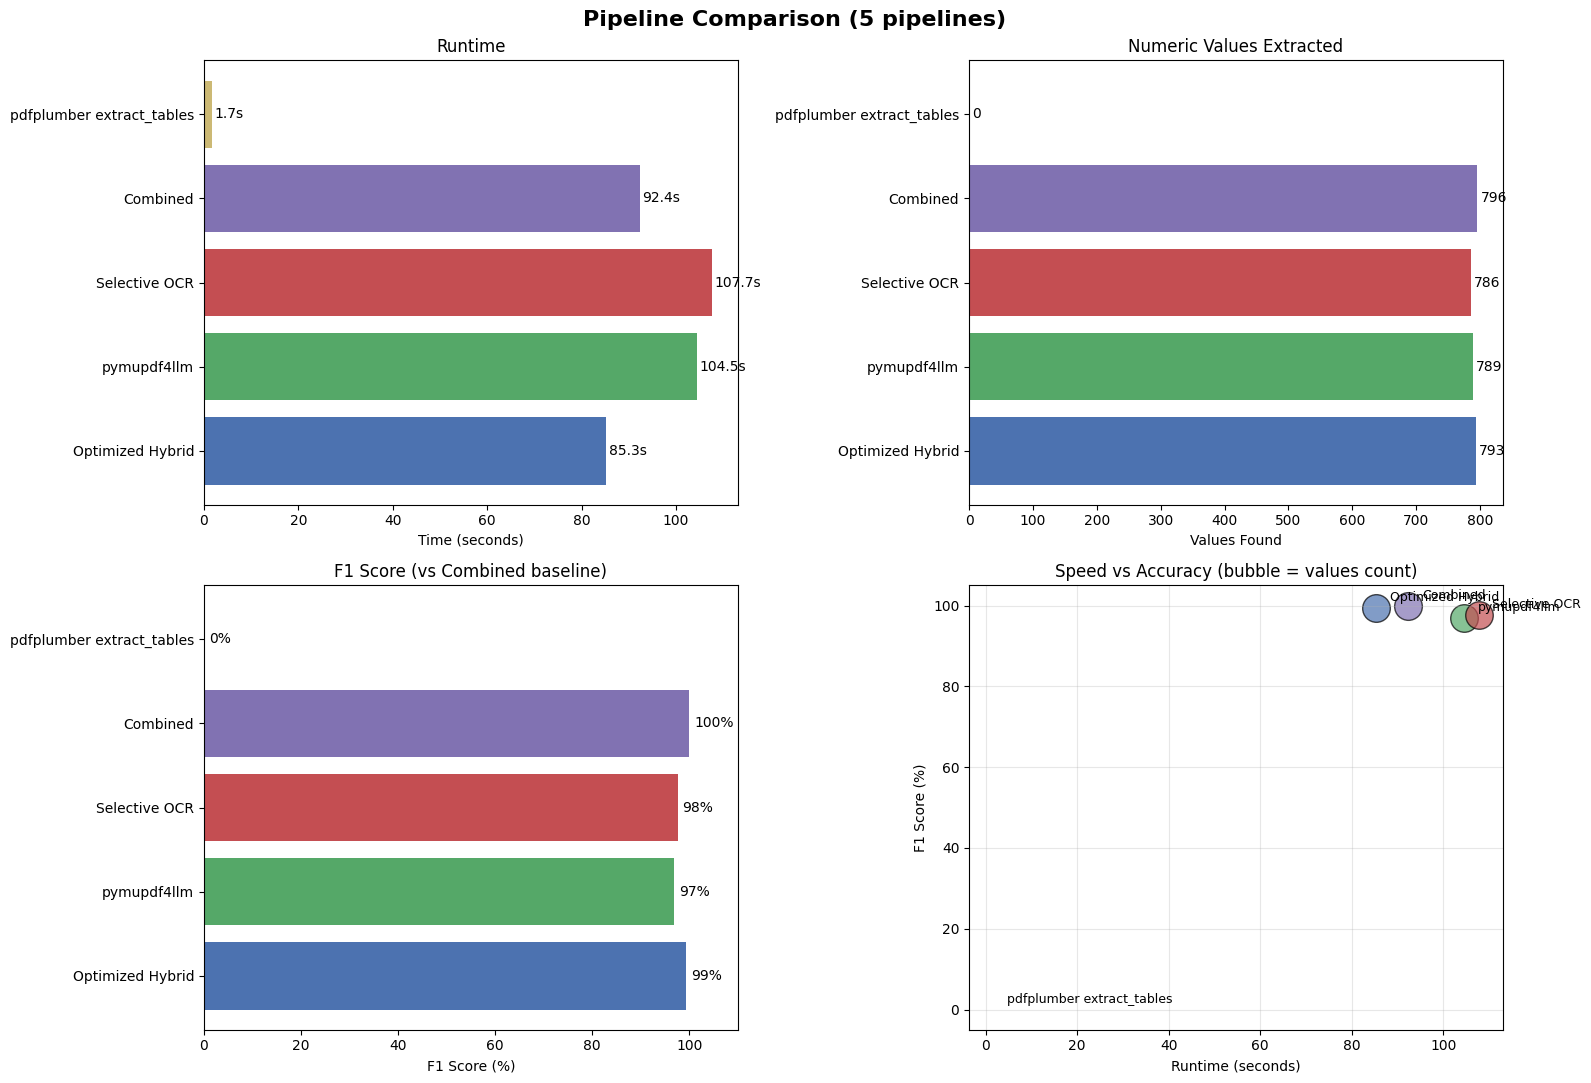

In [23]:
import matplotlib.pyplot as plt

names = list(TIMINGS.keys())
times = [TIMINGS[n] for n in names]
vals = [len(PIPELINE_VALUES[n]) for n in names]
f1s = []
for n in names:
    m = compute_metrics(PIPELINE_VALUES[n], baseline_values)
    f1s.append(m["f1"] * 100)

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"][:len(names)]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Pipeline Comparison (5 pipelines)", fontsize=16, fontweight="bold")

# Runtime
ax = axes[0, 0]
bars = ax.barh(names, times, color=colors)
ax.set_xlabel("Time (seconds)")
ax.set_title("Runtime")
for bar, t in zip(bars, times):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{t:.1f}s", va="center", fontsize=10)

# Values found
ax = axes[0, 1]
bars = ax.barh(names, vals, color=colors)
ax.set_xlabel("Values Found")
ax.set_title("Numeric Values Extracted")
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(v), va="center", fontsize=10)

# F1 Score
ax = axes[1, 0]
bars = ax.barh(names, f1s, color=colors)
ax.set_xlabel("F1 Score (%)")
ax.set_title("F1 Score (vs Combined baseline)")
ax.set_xlim(0, 110)
for bar, f in zip(bars, f1s):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"{f:.0f}%", va="center", fontsize=10)

# Speed vs Accuracy scatter
ax = axes[1, 1]
for i, n in enumerate(names):
    ax.scatter(times[i], f1s[i], s=vals[i] * 0.5, c=colors[i], alpha=0.7, edgecolors="black")
    ax.annotate(n, (times[i], f1s[i]), textcoords="offset points",
                xytext=(10, 5), fontsize=9)
ax.set_xlabel("Runtime (seconds)")
ax.set_ylabel("F1 Score (%)")
ax.set_title("Speed vs Accuracy (bubble = values count)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 15. Export All Results

Save every pipeline's output into `extraction_output_v2/` for side-by-side analysis:
- CSVs + markdown per table
- Per-pipeline values JSON
- Metadata and comparison summary

In [19]:
import shutil

out_dir = config.output_dir
if out_dir.exists():
    shutil.rmtree(out_dir)
out_dir.mkdir(parents=True, exist_ok=True)

# ── 1. Optimized Hybrid ──
dir_opt = out_dir / "01_optimized_hybrid"
dir_opt.mkdir(parents=True)
for t in optimized_tables:
    if t.df is not None and not t.df.empty:
        t.df.to_csv(dir_opt / f"table_p{t.page}_t{t.table_idx}.csv", index=False)
        (dir_opt / f"table_p{t.page}_t{t.table_idx}.md").write_text(
            t.df.to_markdown(index=False))
pd.DataFrame({"value": optimized_values}).to_csv(dir_opt / "values.csv", index=False)
print(f"✓ 01_optimized_hybrid/: {len([t for t in optimized_tables if t.df is not None and not t.df.empty])} tables, {len(optimized_values)} values")

# ── 2. pymupdf4llm ──
dir_md = out_dir / "02_pymupdf4llm"
dir_md.mkdir(parents=True)
(dir_md / "full_markdown.md").write_text(pymupdf4llm_full_md, encoding="utf-8")
for i, chunk in enumerate(pymupdf4llm_md):
    (dir_md / f"page_{i+1}.md").write_text(chunk["text"], encoding="utf-8")
pd.DataFrame({"value": md_values}).to_csv(dir_md / "values.csv", index=False)
print(f"✓ 02_pymupdf4llm/: {len(pymupdf4llm_md)} pages, {len(md_values)} values")

# ── 3. Selective OCR ──
dir_sel = out_dir / "03_selective_ocr"
dir_sel.mkdir(parents=True)
sel_export = [{
    "page": p["page"], "ocr_applied": p["ocr_applied"],
    "ocr_time": p["ocr_time"], "spans": p["blocks"],
} for p in selective_pages]
(dir_sel / "spans_by_page.json").write_text(
    json.dumps(sel_export, indent=2, ensure_ascii=False), encoding="utf-8")
pd.DataFrame({"value": selective_values}).to_csv(dir_sel / "values.csv", index=False)
print(f"✓ 03_selective_ocr/: {len(selective_pages)} pages, {len(selective_values)} values")

# ── 4. Combined ──
dir_comb = out_dir / "04_combined"
dir_comb.mkdir(parents=True)
for t in combined_tables:
    if t.df is not None and not t.df.empty:
        t.df.to_csv(dir_comb / f"table_p{t.page}_t{t.table_idx}.csv", index=False)
        (dir_comb / f"table_p{t.page}_t{t.table_idx}.md").write_text(
            t.df.to_markdown(index=False))
pd.DataFrame({"value": combined_values}).to_csv(dir_comb / "values.csv", index=False)
print(f"✓ 04_combined/: {len([t for t in combined_tables if t.df is not None and not t.df.empty])} tables, {len(combined_values)} values")

# ── Comparison summary ──
pd.DataFrame(comparison_rows).to_csv(out_dir / "comparison.csv", index=False)
with open(out_dir / "timings.json", "w") as f:
    json.dump(TIMINGS, f, indent=2)
with open(out_dir / "all_pipeline_values.json", "w") as f:
    json.dump({k: v for k, v in PIPELINE_VALUES.items()}, f, indent=2, ensure_ascii=False)

print(f"\n{'='*60}")
total_files = sum(1 for _ in out_dir.rglob("*") if _.is_file())
print(f"Total: {total_files} files in {out_dir}/")
for folder in sorted(out_dir.iterdir()):
    if folder.is_dir():
        files = sorted(folder.iterdir())
        print(f"  {folder.name}/  ({len(files)} files)")
print(f"  comparison.csv + timings.json + all_pipeline_values.json")

✓ 01_optimized_hybrid/: 23 tables, 793 values
✓ 02_pymupdf4llm/: 8 pages, 789 values
✓ 03_selective_ocr/: 8 pages, 786 values
✓ 04_combined/: 22 tables, 796 values

Total: 107 files in extraction_output_v2/
  01_optimized_hybrid/  (47 files)
  02_pymupdf4llm/  (10 files)
  03_selective_ocr/  (2 files)
  04_combined/  (45 files)
  comparison.csv + timings.json + all_pipeline_values.json
